# **MIS444 Project**



The following project belongs to Afia Anjum, ID: 22204123 under the supervision of Dr. Najmul Hasan, Associate Professor of Brac Business School.

The objective of this project is to predict whether an online visitor will make a purchase or not based on their browsing behavior and session-related features.

**Column Description**

**Administrative:** Number of administrative pages (e.g., account, login, settings) visited.

**Administrative_Duration**: Total time (in seconds) spent on administrative pages.

**Informational:** Number of informational pages visited (e.g., about us, policies).

**Informational_Duration:** Total time spent on informational pages.

**ProductRelated:** Number of product-related pages visited (e.g., product details).

ProductRelated_Duration: Total time spent on product-related pages.

**BounceRates:** Percentage of visitors who leave after viewing only one page.

**ExitRates:** Percentage of exits from a specific page (how often users leave from it).

**PageValues:** Average value of a page based on how often it leads to a transaction.

**SpecialDay:** Indicates closeness to a special day (e.g., holidays like Valentine's Day). Value ranges from 0 to 1.

**Month:** Month of the session (e.g., Feb, Mar, etc.).

**OperatingSystems:**
Encoded value representing the user’s operating system.

**Browser:** Encoded value representing the user’s browser.

**Region:** Encoded region/location of the user.

**TrafficType:** Encoded type of traffic source (e.g., direct, referral, ads).

**VisitorType:** Type of visitor (Returning_Visitor, New_Visitor, Other).

**Weekend:** Boolean value indicating whether the session occurred on a weekend.

**Revenue**
Target variable:
True → user made a purchase
False → no purchase

In [3]:
import pandas as pd
file_path = r"/content/online_shoppers_intention.csv"
df=pd.read_csv(file_path)


In [4]:
# Numerical computing library for handling arrays and mathematical operations
import numpy as np

# Data manipulation and analysis library (used for DataFrames)
import pandas as pd

# Visualization library for statistical plots (built on matplotlib)
import seaborn as sns

# Basic plotting library for graphs and charts
import matplotlib.pyplot as plt

# Support Vector Machine classifiers
from sklearn.svm import SVC, LinearSVC

# Sequential model API for building neural networks (deep learning)
from tensorflow.keras.models import Sequential

# Decision Tree classifier for classification tasks
from sklearn.tree import DecisionTreeClassifier

# Tool to display confusion matrix visually
from sklearn.metrics import ConfusionMatrixDisplay

# Random Forest classifier (ensemble of decision trees)
from sklearn.ensemble import RandomForestClassifier

# Splits dataset into training and testing sets
from sklearn.model_selection import train_test_split

# LabelEncoder converts categorical labels into numeric form
# StandardScaler standardizes features (mean=0, std=1)
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Linear Regression for regression tasks
# Logistic Regression for classification tasks
from sklearn.linear_model import LinearRegression, LogisticRegression

# Layers used in building neural networks
# Dense = fully connected layer
# Dropout = prevents overfitting
# Conv2D = convolutional layer (for images)
# MaxPooling2D = reduces spatial dimensions
# Flatten = converts 2D data to 1D
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten, Dense

# Evaluation metrics:
# mean_squared_error = regression error metric
# accuracy_score = classification accuracy
# f1_score = harmonic mean of precision and recall
# precision_score = true positives / predicted positives
# recall_score = true positives / actual positives
# confusion_matrix = table of predictions vs actual
# classification_report = detailed performance summary
# roc_curve = plots true positive rate vs false positive rate
# auc = area under ROC curve
from sklearn.metrics import mean_squared_error, accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report, roc_curve, auc

# Ensures plots appear inside Jupyter Notebook
%matplotlib inline

# Suppresses warning messages for cleaner output
import warnings
warnings.filterwarnings("ignore")

**DATA PREPROCESSING**

checking for missing values, outliers and duplicates

In [5]:
null_counts = df.isnull().sum()
print(null_counts)
#as we can confirm, there are no missing values

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


In [ ]:
#To check for duplicated rows
df.duplicated().sum()
#this indicates that there are 125 duplicate rows in the dataset

np.int64(125)

In [ ]:
#to remove duplicate values
df.drop_duplicates(inplace=True)

print("Duplicates removed")

Duplicates removed


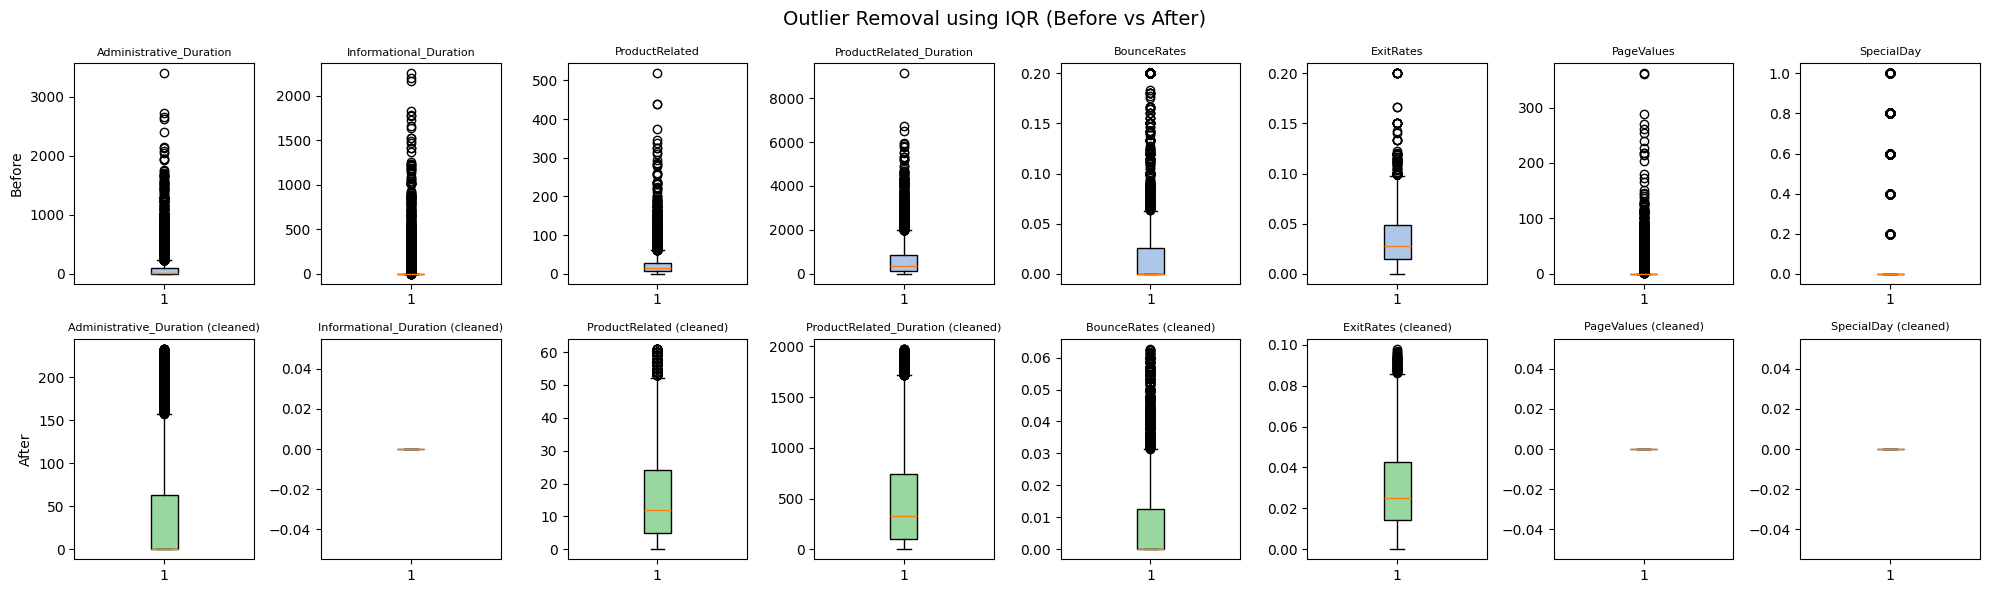

                   feature  outliers  lower_fence  upper_fence
0  Administrative_Duration      1172     -139.884      233.141
1   Informational_Duration      1862        0.000        0.000
2           ProductRelated       691      -27.000       61.000
3  ProductRelated_Duration       506    -1008.875     1975.592
4              BounceRates      1171       -0.038        0.063
5                ExitRates       349       -0.036        0.099
6               PageValues      1092        0.000        0.000
7               SpecialDay       594        0.000        0.000


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('online_shoppers_intention.csv')

# Select continuous features (adjust if needed)
continuous_feats = [
    'Administrative_Duration',
    'Informational_Duration',
    'ProductRelated',
    'ProductRelated_Duration',
    'BounceRates',
    'ExitRates',
    'PageValues',
    'SpecialDay'
]

fig, axes = plt.subplots(2, len(continuous_feats), figsize=(20, 6))
outlier_summary = []

for i, col in enumerate(continuous_feats):

    # Compute IQR
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

    # Count outliers
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()

    outlier_summary.append({
        'feature': col,
        'outliers': n_out,
        'lower_fence': round(lo, 3),
        'upper_fence': round(hi, 3)
    })

    # 🔹 Before boxplot
    axes[0, i].boxplot(df[col], vert=True, patch_artist=True,
                       boxprops=dict(facecolor='#AEC6E8'))
    axes[0, i].set_title(col, fontsize=8)

    # 🔹 Remove outliers (filtering instead of capping)
    df = df[(df[col] >= lo) & (df[col] <= hi)]

    # 🔹 After boxplot
    axes[1, i].boxplot(df[col], vert=True, patch_artist=True,
                       boxprops=dict(facecolor='#98D8A0'))
    axes[1, i].set_title(f'{col} (cleaned)', fontsize=8)

# Labels
axes[0, 0].set_ylabel('Before', fontsize=10)
axes[1, 0].set_ylabel('After', fontsize=10)

plt.suptitle('Outlier Removal using IQR (Before vs After)', fontsize=14)
plt.tight_layout()
plt.show()

# Summary table
outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df)

In [ ]:
df = df[~((df[current_numerical_features] < (Q1 - 1.5 * IQR)) |
          (df[current_numerical_features] > (Q3 + 1.5 * IQR))).any(axis=1)]

print("Outliers removed")

Outliers removed


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Install imbalanced-learn if not already installed
# !pip install imbalanced-learn

from imblearn.over_sampling import SMOTE
from collections import Counter

# Separate features (X) and target (y)
X = df.drop('Revenue', axis=1)
y = df['Revenue']

# Check class distribution before SMOTE
print("Before SMOTE:", Counter(y))

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Check class distribution after SMOTE
print("After SMOTE:", Counter(y_resampled))

Before SMOTE: Counter({0: 10422, 1: 1908})
After SMOTE: Counter({0: 10422, 1: 10422})


In [6]:
df.describe(include='all')

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330,12330.000000,12330.000000,12330.000000,12330.000000,12330,12330,12330
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,NaN,NaN,NaN,NaN,3,2,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,May,NaN,NaN,NaN,NaN,Returning_Visitor,False,False
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3364,NaN,NaN,NaN,NaN,10551,9462,10422
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,NaN,2.124006,2.357097,3.147364,4.069586,NaN,NaN,NaN
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,NaN,0.911325,1.717277,2.401591,4.025169,NaN,NaN,NaN
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,1.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,NaN,2.000000,2.000000,1.000000,2.000000,NaN,NaN,NaN
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,NaN,2.000000,2.000000,3.000000,2.000000,NaN,NaN,NaN
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,NaN,3.000000,2.000000,4.000000,4.000000,NaN,NaN,NaN


Data Transformation

In [ ]:

from sklearn.preprocessing import LabelEncoder, StandardScaler

file_path = r"/content/online_shoppers_intention.csv"
df=pd.read_csv(file_path)


categorical_cols = ['Month', 'VisitorType', 'Weekend']

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])


scaler = StandardScaler()

# Select numerical columns (exclude target)
num_cols = df.drop('Revenue', axis=1).columns

df[num_cols] = scaler.fit_transform(df[num_cols])

# Encode Target Variable

df['Revenue'] = df['Revenue'].astype(int)

print("Data Transformation Complete")
df.head()

#This code was used to dataset for machine learning. It converts categorical
#columns like Month and VisitorType into numeric values using Label Encoding,
#since models cannot handle text directly.
#Then it standardizes all input features so they are on the same scale,
#which improves model performance.
#Finally, it ensures the target variable Revenue is in numeric form (0 or 1),
#making the data ready for training models.

Data Transformation Complete


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,3.667189,3.229316,-0.317178,-0.308821,-1.334959,-1.233426,-0.790293,-0.894178,-0.762629,0.407786,-0.550552,0
1,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.590903,-0.457683,1.171473,-0.317178,-0.308821,-1.334959,-0.136078,-0.207952,-0.894178,-0.514182,0.407786,-0.550552,0
2,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,3.667189,3.229316,-0.317178,-0.308821,-1.334959,2.058618,-0.790293,2.437081,-0.265735,0.407786,-0.550552,0
3,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.622954,0.573535,1.994610,-0.317178,-0.308821,-1.334959,0.961270,-0.207952,-0.477771,-0.017289,0.407786,-0.550552,0
4,-0.696993,-0.457191,-0.396478,-0.244931,-0.488636,-0.296430,-0.045196,0.142551,-0.317178,-0.308821,-1.334959,0.961270,0.374389,-0.894178,-0.017289,0.407786,1.816360,0


Exploratory Data Analysis (EDA)

In [ ]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  float64
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  float64
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  float64
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  float64
 11  OperatingSystems         12330 non-null  float64
 12  Browser                  12330 non-null  float64
 13  Region                   12330 non-null  float64
 14  TrafficType           

In [ ]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,3.667189,3.229316,-0.317178,-0.308821,-1.334959,-1.233426,-0.790293,-0.894178,-0.762629,0.407786,-0.550552,0
1,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.590903,-0.457683,1.171473,-0.317178,-0.308821,-1.334959,-0.136078,-0.207952,-0.894178,-0.514182,0.407786,-0.550552,0
2,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,3.667189,3.229316,-0.317178,-0.308821,-1.334959,2.058618,-0.790293,2.437081,-0.265735,0.407786,-0.550552,0
3,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.622954,0.573535,1.994610,-0.317178,-0.308821,-1.334959,0.961270,-0.207952,-0.477771,-0.017289,0.407786,-0.550552,0
4,-0.696993,-0.457191,-0.396478,-0.244931,-0.488636,-0.296430,-0.045196,0.142551,-0.317178,-0.308821,-1.334959,0.961270,0.374389,-0.894178,-0.017289,0.407786,1.816360,0


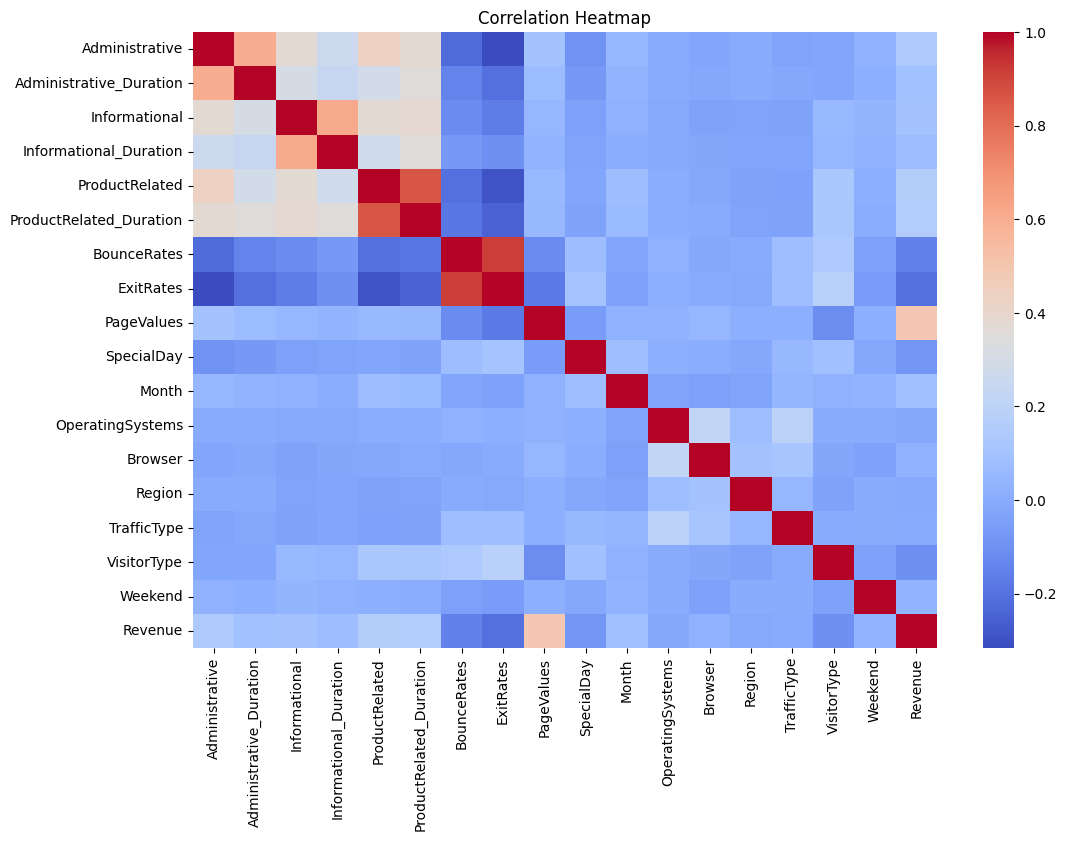

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

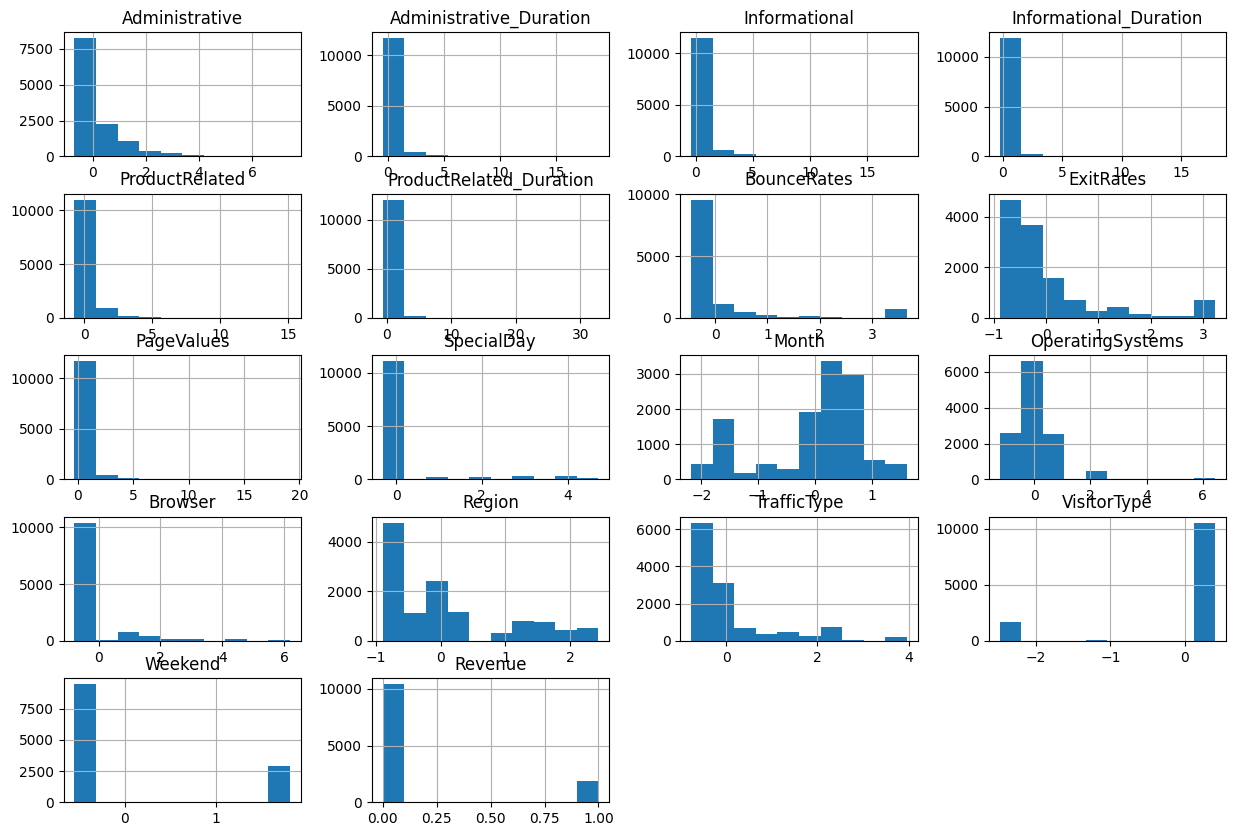

In [ ]:
df.hist(figsize=(15,10))
plt.show()

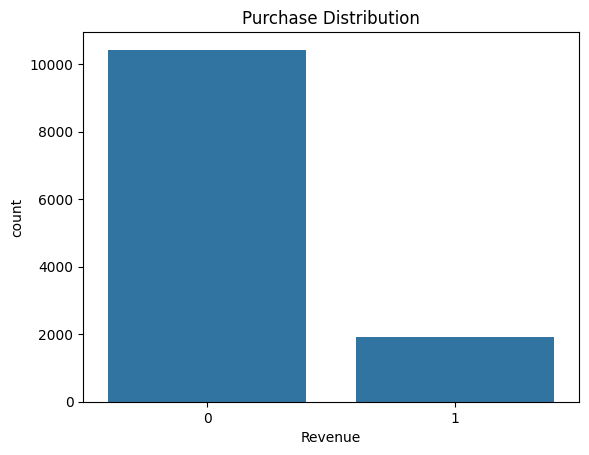

In [ ]:
sns.countplot(x='Revenue', data=df)
plt.title("Purchase Distribution")
plt.show()

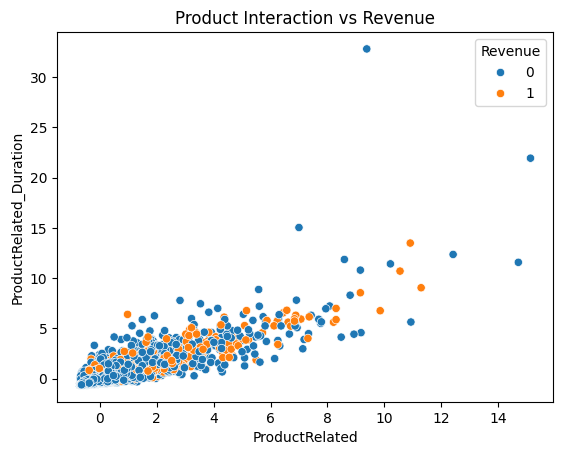

In [ ]:
sns.scatterplot(x='ProductRelated', y='ProductRelated_Duration', hue='Revenue', data=df)
plt.title("Product Interaction vs Revenue")
plt.show()

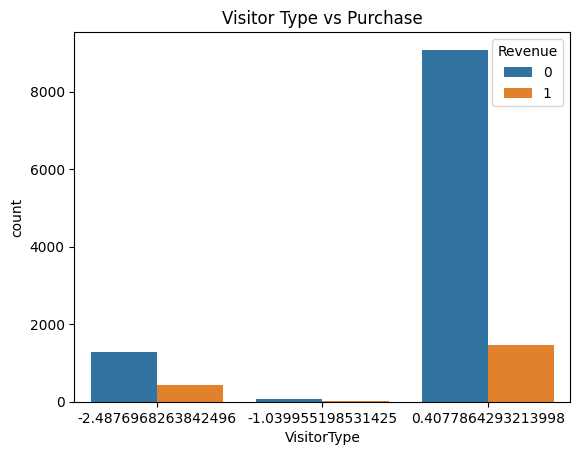

In [ ]:
sns.countplot(x='VisitorType', hue='Revenue', data=df)
plt.title("Visitor Type vs Purchase")
plt.show()

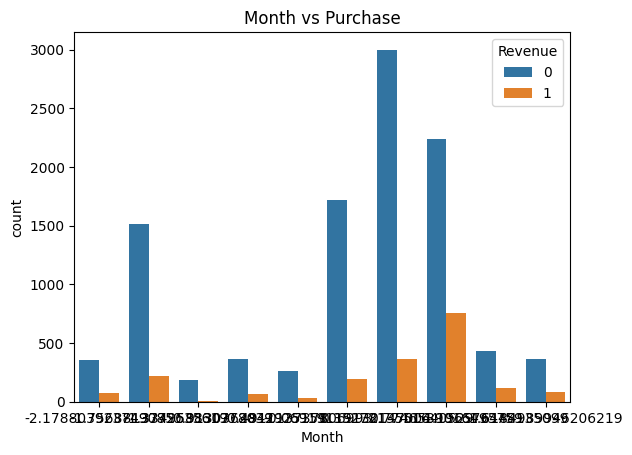

In [ ]:
sns.countplot(x='Month', hue='Revenue', data=df)
plt.title("Month vs Purchase")
plt.show()

FEATURE SELECTION

In [ ]:
import pandas as pd

df = pd.read_csv('online_shoppers_intention.csv')

features_to_remove = [
    'Administrative',
    'Informational',
    'OperatingSystems',
    'Browser',
    'Region',
    'TrafficType',
    'Weekend',
    'SpecialDay'
]

df = df.drop(columns=features_to_remove, errors='ignore')

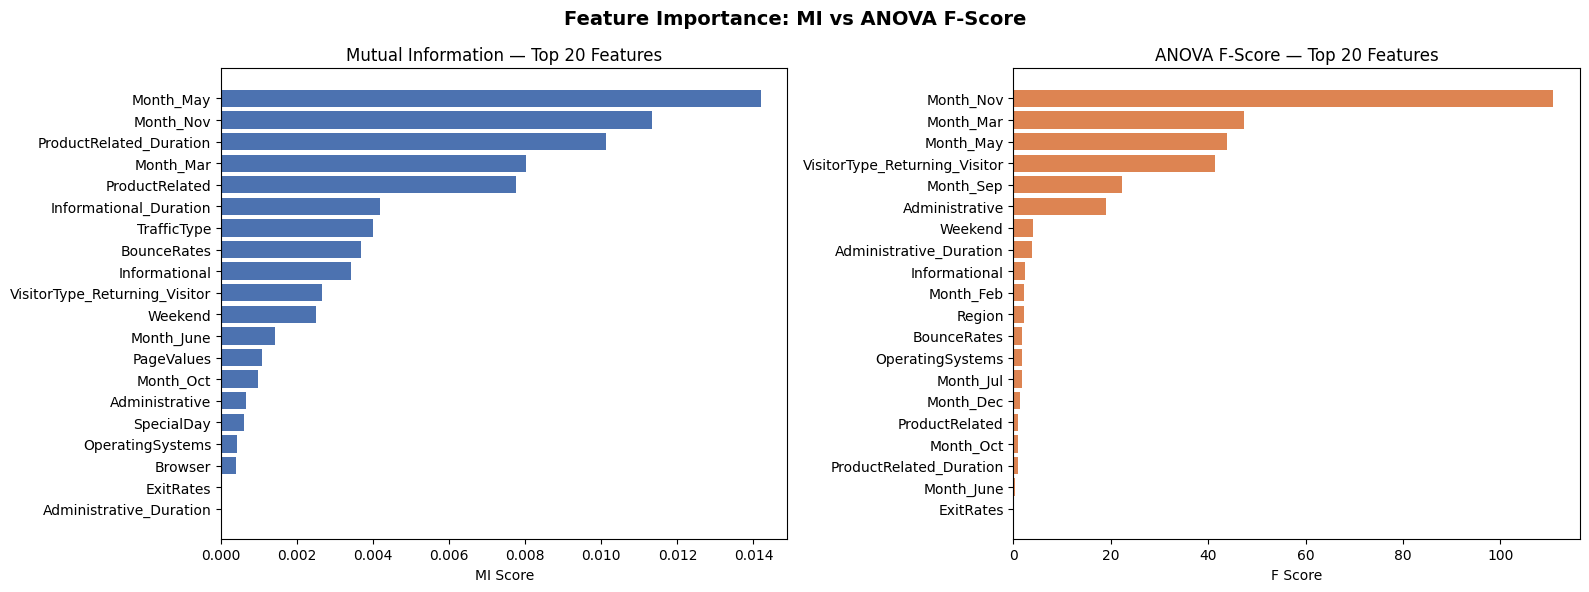


Selected 25 features for modelling:
['Month_May', 'Month_Nov', 'ProductRelated_Duration', 'Month_Mar', 'ProductRelated', 'Informational_Duration', 'TrafficType', 'BounceRates', 'Informational', 'VisitorType_Returning_Visitor', 'Weekend', 'Month_June', 'PageValues', 'Month_Oct', 'Administrative', 'SpecialDay', 'OperatingSystems', 'Browser', 'ExitRates', 'Administrative_Duration', 'Month_Dec', 'Region', 'Month_Jul', 'Month_Feb', 'Month_Sep']


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif, SelectKBest, f_classif

# Categorical columns that need to be encoded for feature selection
categorical_cols_for_encoding = ['Month', 'VisitorType']

# One-hot encode the categorical columns
df = pd.get_dummies(df, columns=categorical_cols_for_encoding, drop_first=True)

# Define X and y
X = df.drop(columns=['Revenue'])
y = df['Revenue']

# 🔹 Mutual Information
mi = mutual_info_classif(X, y, random_state=42)
mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)

# 🔹 ANOVA F-score
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X, y)
fscores = pd.Series(selector.scores_, index=X.columns).sort_values(ascending=False)

# 🔹 Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 20 MI features
top_mi = mi_series.head(20)
axes[0].barh(top_mi.index[::-1], top_mi.values[::-1], color='#4C72B0')
axes[0].set_title('Mutual Information — Top 20 Features')
axes[0].set_xlabel('MI Score')

# Top 20 ANOVA features
top_f = fscores.head(20)
axes[1].barh(top_f.index[::-1], top_f.values[::-1], color='#DD8452')
axes[1].set_title('ANOVA F-Score — Top 20 Features')
axes[1].set_xlabel('F Score')

plt.suptitle('Feature Importance: MI vs ANOVA F-Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_selection.png', bbox_inches='tight')
plt.show()

# 🔹 Select top features (example: top 25 from MI)
top_features = mi_series.head(25).index.tolist()

print(f"\nSelected {len(top_features)} features for modelling:")
print(top_features)


In [ ]:
from sklearn.model_selection import train_test_split

# Split the preprocessed dataframe 'df'
X = df.drop('Revenue', axis=1)
y = df['Revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Data split updated with preprocessed features.")

Data split updated with preprocessed features.


In [ ]:
print(df.dtypes)

Administrative_Duration          float64
Informational_Duration           float64
ProductRelated                   float64
ProductRelated_Duration          float64
BounceRates                      float64
ExitRates                        float64
PageValues                       float64
Revenue                            int64
Month_Dec                        float64
Month_Feb                        float64
Month_Jul                        float64
Month_June                       float64
Month_Mar                        float64
Month_May                        float64
Month_Nov                        float64
Month_Oct                        float64
Month_Sep                        float64
VisitorType_Other                float64
VisitorType_Returning_Visitor    float64
dtype: object


**MODEL BUILDING**

Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Initialize and train the model on the updated split
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))

Logistic Regression Accuracy: 0.8811841038118411


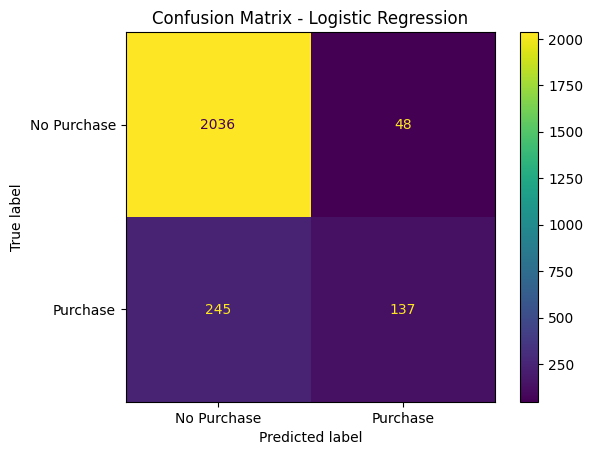

In [ ]:
cm_matrix = confusion_matrix(y_test, y_pred_log)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm_matrix,
                                    display_labels=['No Purchase', 'Purchase'])
cm_display.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

Interpretation: Typically shows a balanced distribution between TN and TP
However, it often produces a noticeable number of False Negatives (FN)
→ meaning it fails to detect some actual buyers
This happens because Logistic Regression assumes a linear relationship, while user behavior is more complex. The model performs reliably as a baseline but struggles to capture non-linear patterns in customer behavior, leading to missed purchase predictions.

Decision Tree Classifier


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.8965936739659367


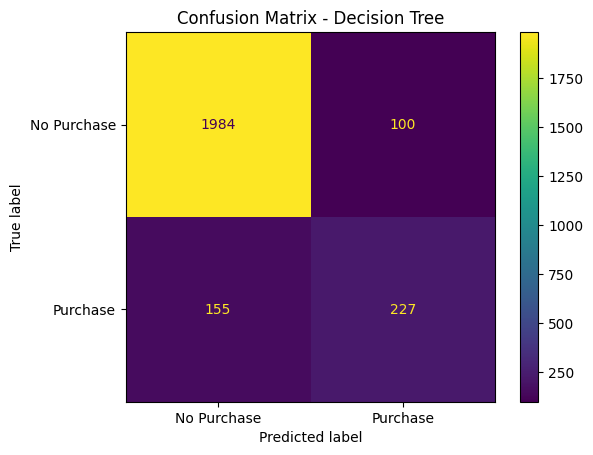

In [ ]:
cm_matrix = confusion_matrix(y_test, y_pred_dt)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm_matrix,
                                    display_labels=['No Purchase', 'Purchase'])
cm_display.plot()
plt.title("Confusion Matrix - Decision Tree")
plt.show()

Usually achieves high True Positives (TP) but at a cost
Often increases False Positives (FP)
→ predicts purchases that don’t actually happen
This indicates overfitting, especially if the tree is deep
The model captures complex patterns but may overfit the training data, resulting in less reliable generalization and more incorrect positive predictions.

Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.9002433090024331


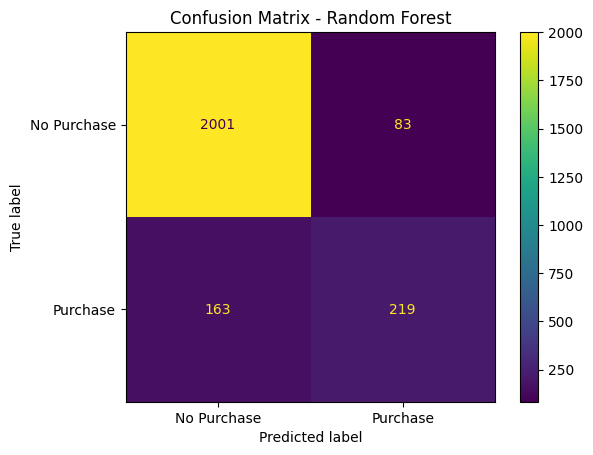

In [ ]:
cm_matrix = confusion_matrix(y_test, y_pred_rf)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm_matrix,
                                    display_labels=['No Purchase', 'Purchase'])
cm_display.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

Shows high TN and TP simultaneously
Keeps both False Positives (FP) and False Negatives (FN) relatively low
Works well because it combines multiple trees and reduces overfitting
This model provides the most balanced and accurate predictions, effectively capturing complex relationships while minimizing both missed and incorrect purchase predictions.

KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.8852392538523925


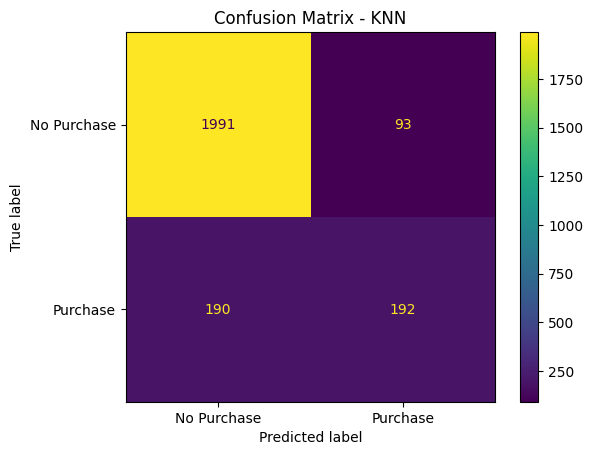

In [ ]:
cm_matrix = confusion_matrix(y_test, y_pred_knn)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm_matrix,
                                    display_labels=['No Purchase', 'Purchase'])
cm_display.plot()
plt.title("Confusion Matrix - KNN")
plt.show()

Performance depends heavily on scaling and choice of k
Often shows higher False Negatives (FN)
→ misses actual buyers
Can also fluctuate depending on data distribution

The model is sensitive to feature scaling and local data structure, which can lead to inconsistent performance and missed purchase predictions.

In [ ]:

from sklearn.metrics import accuracy_score

accuracies = {
    "Logistic Regression": accuracy_score(y_test, y_pred_log),
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "KNN": accuracy_score(y_test, y_pred_knn)
}

average_accuracy = sum(accuracies.values()) / len(accuracies)

for model, acc in accuracies.items():
    print(f"{model} Accuracy: {round(acc, 4)}")

print("\nAverage Accuracy:", round(average_accuracy, 4))

Logistic Regression Accuracy: 0.8812
Decision Tree Accuracy: 0.8966
Random Forest Accuracy: 0.9002
KNN Accuracy: 0.8852

Average Accuracy: 0.8908


the algorithms was originally run to see the normal accuracy with all features, it was found to have an average of 85% accuracy. I have decided to re run the same algorithms with some redunant features removed. The rerun models is shown to have a better accuracy of 89%

**MODEL OPTIMIZATION**

Logistic Regression (Optimized)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_model_opt = LogisticRegression(
    max_iter=500,
    solver='lbfgs',
    C=0.5   # regularization strength (smaller = more regularization)
)

log_model_opt.fit(X_train, y_train)
y_pred_log_opt = log_model_opt.predict(X_test)

print("Optimized Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log_opt))

Optimized Logistic Regression Accuracy: 0.8811841038118411


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid_log = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [200, 500]
}

grid_log = GridSearchCV(
    LogisticRegression(),
    param_grid_log,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_log.fit(X_train, y_train)

print("Best Parameters:", grid_log.best_params_)
print("Best Score:", grid_log.best_score_)

y_pred_log_gs = grid_log.predict(X_test)

Best Parameters: {'C': 10, 'max_iter': 200, 'solver': 'lbfgs'}
Best Score: 0.8856449492078147


Decision Tree (Optimized)


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model_opt = DecisionTreeClassifier(
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt_model_opt.fit(X_train, y_train)
y_pred_dt_opt = dt_model_opt.predict(X_test)

print("Optimized Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt_opt))

Optimized Decision Tree Accuracy: 0.8941605839416058


In [ ]:
from sklearn.tree import DecisionTreeClassifier

param_grid_dt = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

print("Best Parameters:", grid_dt.best_params_)
print("Best Score:", grid_dt.best_score_)

y_pred_dt_gs = grid_dt.predict(X_test)

Best Parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Score: 0.8994316785735214


Random Forest (Optimized)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model_opt = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_model_opt.fit(X_train, y_train)
y_pred_rf_opt = rf_model_opt.predict(X_test)

print("Optimized Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf_opt))

Optimized Random Forest Accuracy: 0.9055150040551501


In [ ]:
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best Parameters:", grid_rf.best_params_)
print("Best Score:", grid_rf.best_score_)

y_pred_rf_gs = grid_rf.predict(X_test)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best Score: 0.9079478127130048


KNN (Optimized)


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_model_opt = KNeighborsClassifier(
    n_neighbors=7,
    weights='distance',
    metric='minkowski'
)

knn_model_opt.fit(X_train_scaled, y_train)
y_pred_knn_opt = knn_model_opt.predict(X_test_scaled)

print("Optimized KNN Accuracy:", accuracy_score(y_test, y_pred_knn_opt))

Optimized KNN Accuracy: 0.8844282238442822


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['minkowski', 'euclidean']
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_knn.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_knn.best_params_)
print("Best Score:", grid_knn.best_score_)

y_pred_knn_gs = grid_knn.predict(X_test_scaled)

Best Parameters: {'metric': 'minkowski', 'n_neighbors': 9, 'weights': 'uniform'}
Best Score: 0.8907130131007959


MODEL EVALUATION

Accuracy: 0.8811841038118411
Precision: 0.7405405405405405
Recall: 0.3586387434554974
F1 Score: 0.48324514991181655
Confusion Matrix:
 [[2036   48]
 [ 245  137]]

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.98      0.93      2084
           1       0.74      0.36      0.48       382

    accuracy                           0.88      2466
   macro avg       0.82      0.67      0.71      2466
weighted avg       0.87      0.88      0.86      2466

AUC: 0.888925596165248


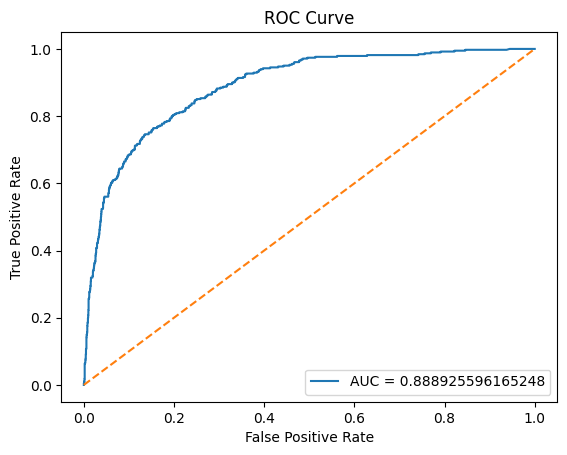

In [ ]:
# Import required metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt

# Example: train a model (Logistic Regression used here)
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Probabilities (needed for ROC-AUC)
y_prob = model.predict_proba(X_test)[:, 1]


# 1. Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


# 2. Precision
precision = precision_score(y_test, y_pred)
print("Precision:", precision)


# 3. Recall
recall = recall_score(y_test, y_pred)
print("Recall:", recall)


# 4. F1 Score
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)


# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)


# 6. Classification Report (all metrics together)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


# 7. ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)

plt.plot(fpr, tpr, label="AUC = " + str(roc_auc))
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

y_pred_log = log_model_opt.predict(X_test)

print("Logistic Regression Report:\n")
print(classification_report(y_test, y_pred_log,
                            target_names=['Not Purchase', 'Purchase']))

Logistic Regression Report:

              precision    recall  f1-score   support

Not Purchase       0.89      0.98      0.93      2084
    Purchase       0.74      0.36      0.48       382

    accuracy                           0.88      2466
   macro avg       0.82      0.67      0.71      2466
weighted avg       0.87      0.88      0.86      2466



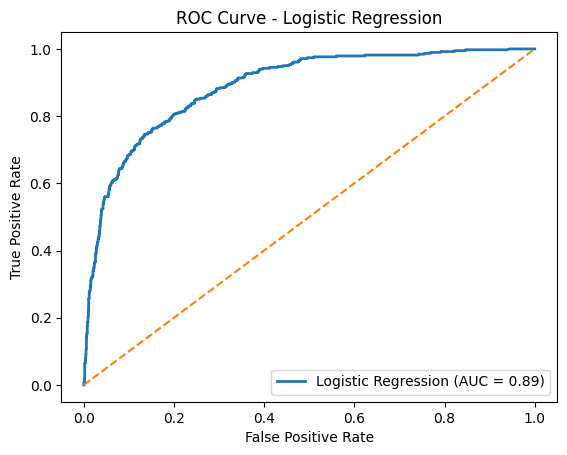

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob_log = log_model_opt.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob_log)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, lw=2, label='Logistic Regression (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc="lower right")
plt.show()

In [ ]:
y_pred_dt = dt_model_opt.predict(X_test)

print("Decision Tree Report:\n")
print(classification_report(y_test, y_pred_dt,
                            target_names=['Not Purchase', 'Purchase']))

Decision Tree Report:

              precision    recall  f1-score   support

Not Purchase       0.91      0.97      0.94      2084
    Purchase       0.74      0.49      0.59       382

    accuracy                           0.89      2466
   macro avg       0.82      0.73      0.76      2466
weighted avg       0.89      0.89      0.89      2466



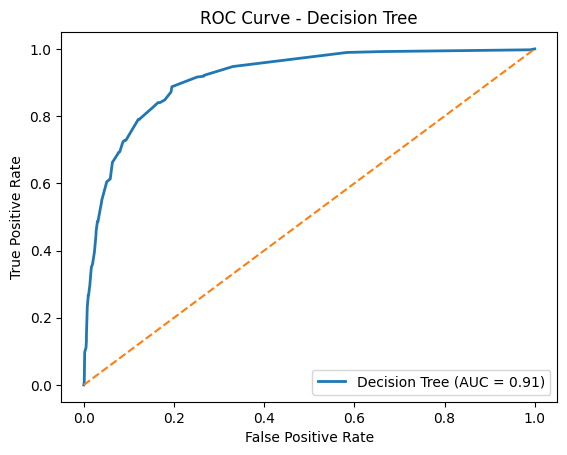

In [ ]:
y_prob_dt = dt_model_opt.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob_dt)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, lw=2, label='Decision Tree (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree')
plt.legend(loc="lower right")
plt.show()

In [ ]:
y_pred_rf = rf_model_opt.predict(X_test)

print("Random Forest Report:\n")
print(classification_report(y_test, y_pred_rf,
                            target_names=['Not Purchase', 'Purchase']))

Random Forest Report:

              precision    recall  f1-score   support

Not Purchase       0.93      0.97      0.95      2084
    Purchase       0.76      0.57      0.65       382

    accuracy                           0.91      2466
   macro avg       0.84      0.77      0.80      2466
weighted avg       0.90      0.91      0.90      2466



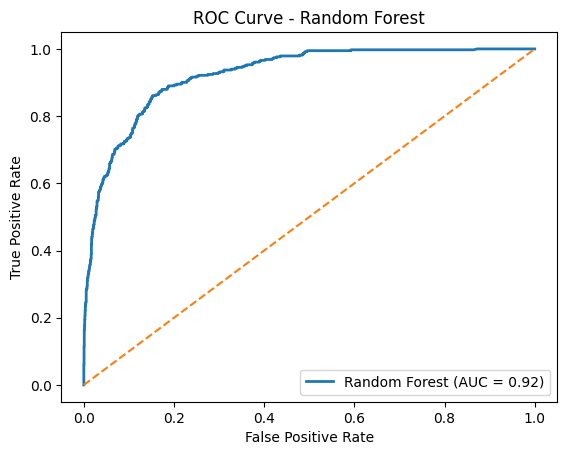

In [ ]:
y_prob_rf = rf_model_opt.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, lw=2, label='Random Forest (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc="lower right")
plt.show()

In [ ]:
y_pred_knn = knn_model_opt.predict(X_test_scaled)

print("KNN Report:\n")
print(classification_report(y_test, y_pred_knn,
                            target_names=['Not Purchase', 'Purchase']))

KNN Report:

              precision    recall  f1-score   support

Not Purchase       0.91      0.96      0.93      2084
    Purchase       0.67      0.49      0.57       382

    accuracy                           0.88      2466
   macro avg       0.79      0.73      0.75      2466
weighted avg       0.87      0.88      0.88      2466



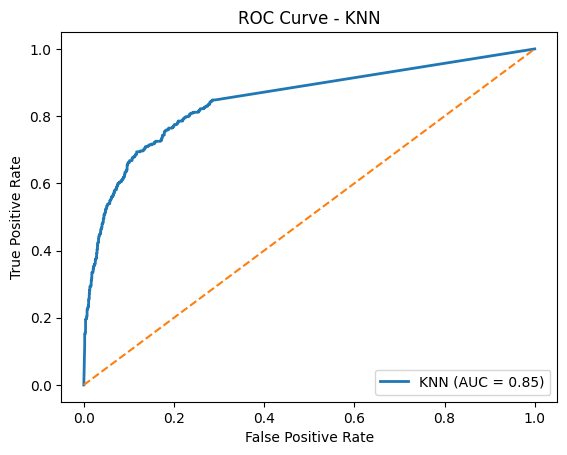

In [ ]:
y_prob_knn = knn_model_opt.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob_knn)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, lw=2, label='KNN (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - KNN')
plt.legend(loc="lower right")
plt.show()

**Interpretation of Key Predictors and Their Impact**

From the given results, we can indentify several predicators that affect the likelihood of a customer ultimately purchasing. Variables such as number of visits, is psoitively assosciated with purchasing intent. **Visitor type** is also a factor since returning visitors haave a higher probability to buying compared to newer ones. Features such as month and weekend actitvity reflect seasonal trends. To summarize, the features that relates to user engagement have the most impact.

**Managerial Implications and Recommendations**

It is recommended that the business can leverage predictive insightd to target potential customers with discounts. Secondly, they could also enchance the customer interaction with website (different touchpoints) to increase conversion rates. It is also recommended that they to implement retention such as loyalty programs.

**Limitations and Areas for Improvement**


The model works well, but it still has some limitations. One issue is **class imbalance**, where one category (like non-buyers) is much larger than the other, which can make the model biased. Even with methods like SMOTE, this problem may not be fully solved.

Another limitation is that the model only uses **past user behavior**. It does not consider other important factors like market trends, economic conditions, or competitor actions, which can also affect buying decisions.

There are also some issues with how data is represented. For example, converting categories into numbers may not always capture their true meaning or relationships.

To improve the model, more advanced techniques like **ensemble models or deep learning** can be used. Adding more data, such as customer demographics or real-time activity, can also make predictions better. Finally, the model should be **updated regularly** so it stays accurate as user behavior changes over time.
